# Immune Profiling of COVID-19 Severity: A Cross-Sectional Analysis

**Dataset**: Stephenson et al., Nature Medicine 2021 (E-MTAB-10026)


## Background

Stephenson et al. profiled peripheral blood mononuclear cells (PBMCs) from COVID-19 patients across severity groups and timepoints, providing insights into immune dynamics during disease progression.

### Important Methodological Notes

**This is an OBSERVATIONAL study, not a randomized trial:**
- Disease severity (Mild vs Severe) is an **outcome**, not a treatment assignment
- Patients are not randomly assigned to severity groups
- Differences between groups reflect disease biology, not causal treatment effects
- We use sctrial's infrastructure for structured comparisons, but interpret results as **descriptive associations**

**Time axis considerations:**
- **Days From Onset (DFO)**: Biological time since symptom onset - captures disease progression
- **Collection_Day**: Calendar time since study enrollment - captures sampling schedule
- These are fundamentally different; we use DFO for biological interpretability

**Analysis strategy:**
Given limited longitudinal pairing in this dataset, we focus on **cross-sectional comparisons** between severity groups at each timepoint, which is the most statistically appropriate approach.


## 1. Setup and Configuration


In [1]:
# Imports - consolidated in one cell
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# Note: We do NOT suppress UserWarning — sctrial issues important
# statistical caveats (e.g. low-cluster reliability) as UserWarnings.

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu  # Import here for use across notebook
from pathlib import Path
import urllib.request

import sctrial as st
import itertools

# Configuration constants
MIN_GENES_FOR_SCORE = 5
MIN_PARTICIPANTS_FOR_COMPARISON = 5
MIN_CELLS_PER_CELLTYPE = 100
SEED = 42
FDR_ALPHA = 0.25  # Exploratory threshold; use 0.05 for confirmatory analyses

pd.options.mode.chained_assignment = None
print(f"sctrial version: {st.__version__ if hasattr(st, '__version__') else 'dev'}")


def _fmt_fdr(v):
    """Format FDR/p-value: scientific notation for very small values."""
    return f"{v:.2e}" if v < 0.001 else f"{v:.3f}"


sctrial version: 0.2.1.dev1


## 2. Data Loading and Processing


In [2]:
# Dataset loaders and helpers
# All available at top-level: st.load_stephenson_data, st.count_paired, st.categorize_celltype
from sctrial.datasets import load_stephenson_data, count_paired, categorize_celltype


In [3]:
# Load data
adata = load_stephenson_data(force_reprocess=False)

print("\n=== Dataset Summary ===")
print(f"Cells: {adata.n_obs:,}")
print(f"Genes: {adata.n_vars:,}")
print(f"Severity groups: {adata.obs['severity'].unique().tolist()}")
print(f"DFO bins: {sorted(adata.obs['dfo_bin'].unique().tolist())}")
print(f"Cell types: {adata.obs['celltype'].nunique()}")
print(f"Participants: {adata.obs['participant_id'].nunique()}")


=== Dataset Summary ===
Cells: 205,202
Genes: 24,929
Severity groups: ['Severe', 'Mild']
DFO bins: ['DFO_0-7', 'DFO_15+', 'DFO_8-14']
Cell types: 50
Participants: 34


/var/folders/71/dc4p4yz15s74z9c69xy6sk_00000gt/T/ipykernel_25564/900064142.py:2: UserWarning: Cached file lacks processing_params metadata; cannot verify it matches current settings. Consider reprocessing with force_reprocess=True.
  adata = load_stephenson_data(force_reprocess=False)


## 3. Sample Size Assessment

Before analysis, we assess sample sizes to determine appropriate statistical methods.


Participants per severity × DFO bin:


dfo_bin,DFO_0-7,DFO_8-14,DFO_15+
severity,,,
Mild,8,11,4
Severe,2,5,4



Longitudinal pairing (DFO 0-7 → 8-14): 0 participants

⚠️  WARNING: Only 0 paired participants available.
   Difference-in-Differences analysis requires ≥5 paired participants.
   This notebook will focus on CROSS-SECTIONAL comparisons instead.


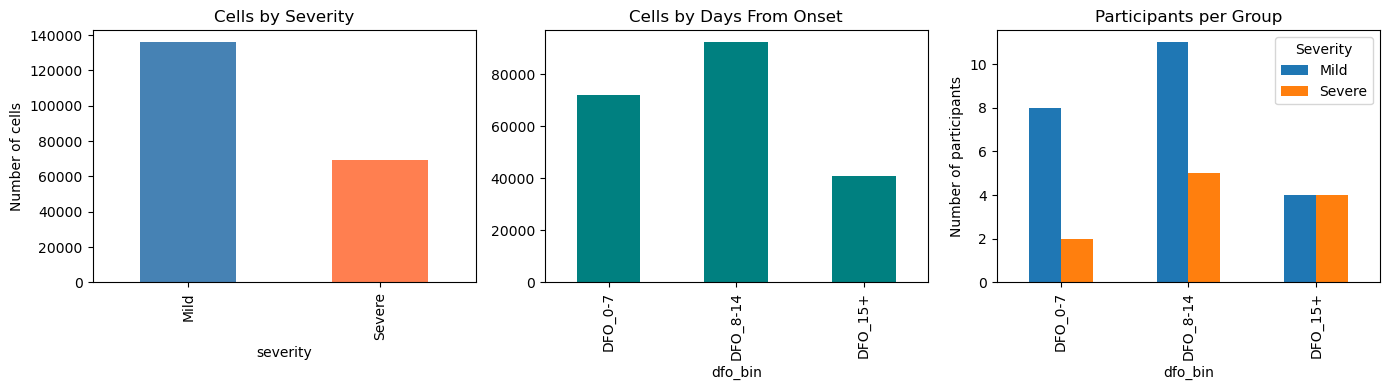

In [4]:
# Sample sizes by severity and timepoint
sample_sizes = (
    adata.obs
    .groupby(["severity", "dfo_bin"], observed=True)["participant_id"]
    .nunique()
    .unstack(fill_value=0)
)
print("Participants per severity × DFO bin:")
display(sample_sizes)

# Check for longitudinal pairing

dfo_visits = ["DFO_0-7", "DFO_8-14"]
n_paired_dfo = count_paired(adata.obs, "dfo_bin", dfo_visits)

print("")
print(f"Longitudinal pairing (DFO 0-7 → 8-14): {n_paired_dfo} participants")

if n_paired_dfo < MIN_PARTICIPANTS_FOR_COMPARISON:
    print("")
    print(f"⚠️  WARNING: Only {n_paired_dfo} paired participants available.")
    print("   Difference-in-Differences analysis requires ≥5 paired participants.")
    print("   This notebook will focus on CROSS-SECTIONAL comparisons instead.")
    CAN_DO_DID = False
else:
    CAN_DO_DID = True

# Visualize sample sizes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Cells by severity
adata.obs["severity"].value_counts().plot(
    kind="bar", ax=axes[0], color=["steelblue", "coral"]
)
axes[0].set_title("Cells by Severity")
axes[0].set_ylabel("Number of cells")

# Cells by DFO
adata.obs["dfo_bin"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="teal"
)
axes[1].set_title("Cells by Days From Onset")

# Participants per group
sample_sizes.T.plot(kind="bar", ax=axes[2])
axes[2].set_title("Participants per Group")
axes[2].set_ylabel("Number of participants")
axes[2].legend(title="Severity")

plt.tight_layout()
plt.show()


## 4. Study Design Configuration

We configure the comparison structure. Note: We use sctrial's `TrialDesign` for convenience, but this is an **observational** comparison, not a randomized trial.


In [5]:
# Add log1p-CPM normalization
if "log1p_cpm" not in adata.layers:
    adata = st.add_log1p_cpm_layer(adata, counts_layer="counts", out_layer="log1p_cpm")
    print("Added log1p_cpm layer")

# Define comparison design
# Note: We call Severe the "treated" group for sctrial compatibility,
# but this is purely for software purposes - there is no treatment!
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col="dfo_bin",
    arm_col="severity",
    arm_treated="Severe",   # Reference group for comparison
    arm_control="Mild",
    celltype_col="celltype",
)

# Available visits for analysis
available_visits = sorted(adata.obs["dfo_bin"].unique().tolist())
print(f"Available DFO bins: {available_visits}")

# Covariates - match actual column names in the dataset
covariate_mapping = {
    "Age_interval": "age",
    "Sex": "sex", 
    "Site": "site",
    "Smoker": "smoker",
}
covariates = [c for c in covariate_mapping.keys() if c in adata.obs.columns]
print(f"Available covariates: {covariates}")

# Check covariate distributions
if covariates:
    print("\nCovariate summary by severity:")
    for cov in covariates[:3]:  # Show first 3
        print(f"\n{cov}:")
        print(adata.obs.groupby("severity")[cov].value_counts().unstack(fill_value=0))

design

Added log1p_cpm layer
Available DFO bins: ['DFO_0-7', 'DFO_15+', 'DFO_8-14']
Available covariates: ['Age_interval', 'Sex', 'Site', 'Smoker']

Covariate summary by severity:

Age_interval:
Age_interval  (20, 29]  (30, 39]  (40, 49]  (50, 59]  (60, 69]  (70, 79]  \
severity                                                                   
Mild              7446     16252     22525     21651     35854     17798   
Severe               0      5589     15433     32828      4164      2233   

Age_interval  (80, 89]  (90, 99]  
severity                          
Mild             14410         0  
Severe            9019         0  

Sex:
Sex       Female   Male
severity               
Mild       84262  51674
Severe     49556  19710

Site:
Site      Cambridge    Ncl  Sanger
severity                          
Mild          26277  87676   21983
Severe         6397  44275   18594


TrialDesign(participant_col='participant_id', visit_col='dfo_bin', arm_col='severity', arm_treated='Severe', arm_control='Mild', celltype_col='celltype', crossover_col=None, baseline_visit=None, followup_visit=None)

## 4.1 Baseline Covariate Balance (Treated vs Control)

Here we assess baseline covariate balance between severity groups at the earliest visit. Standardized mean differences (SMD) below 0.1 indicate good balance.

Selected baseline visit: DFO_8-14 (treated=5, control=11)


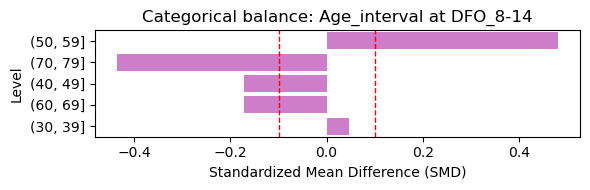

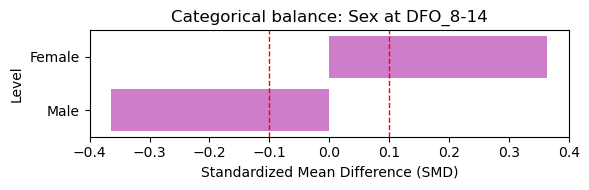

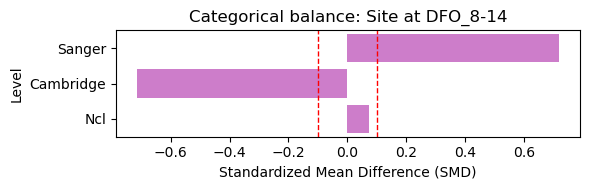

In [6]:
# Baseline covariate balance (select visit with most balanced counts)
covariates = [c for c in ["Age_interval", "Sex", "Site"] if c in adata.obs.columns]
if covariates:
    if "dfo_bin" in adata.obs.columns:
        # Pick visit with max min(n_treated, n_control) at participant-level
        visit_scores = []
        for v in sorted(adata.obs["dfo_bin"].dropna().unique()):
            sub = adata.obs[adata.obs["dfo_bin"] == v]
            if design.participant_col in sub.columns:
                counts = sub.groupby(design.arm_col)[design.participant_col].nunique()
            else:
                counts = sub.groupby(design.arm_col).size()
            n_t = int(counts.get(design.arm_treated, 0))
            n_c = int(counts.get(design.arm_control, 0))
            visit_scores.append((v, n_t, n_c, min(n_t, n_c)))
        # choose visit with largest min(n_t, n_c); tie-breaker by total participants
        visit_scores.sort(key=lambda x: (x[3], x[1]+x[2]), reverse=True)
        visit0, n_t, n_c, _ = visit_scores[0]
        print(f"Selected baseline visit: {visit0} (treated={n_t}, control={n_c})")

        try:
            balance = st.check_covariate_balance(adata, design, covariates, visit=visit0)
            if not balance.empty:
                # Numeric covariates: one figure
                num_bal = balance[balance["level"].isna()].copy()
                if not num_bal.empty:
                    plt.figure(figsize=(6, max(2, 0.4 * len(num_bal))))
                    sns.barplot(data=num_bal, y="covariate", x="smd", color="steelblue")
                    plt.axvline(0.1, color="red", linestyle="--", linewidth=1)
                    plt.axvline(-0.1, color="red", linestyle="--", linewidth=1)
                    plt.title(f"Numeric covariate balance at {visit0}")
                    plt.xlabel("Standardized Mean Difference (SMD)")
                    plt.ylabel("Covariate")
                    plt.tight_layout()
                    plt.show()

                # Categorical covariates: one panel per covariate
                cat_bal = balance[balance["level"].notna()].copy()
                for cov in cat_bal["covariate"].unique():
                    sub = cat_bal[cat_bal["covariate"] == cov].copy()
                    sub = sub.reindex(sub["smd"].abs().sort_values(ascending=False).index)
                    plt.figure(figsize=(6, max(2, 0.35 * len(sub))))
                    sns.barplot(data=sub, y="level", x="smd", color="orchid")
                    plt.axvline(0.1, color="red", linestyle="--", linewidth=1)
                    plt.axvline(-0.1, color="red", linestyle="--", linewidth=1)
                    plt.title(f"Categorical balance: {cov} at {visit0}")
                    plt.xlabel("Standardized Mean Difference (SMD)")
                    plt.ylabel("Level")
                    plt.tight_layout()
                    plt.show()
        except Exception as e:
            print(f"Covariate balance check failed: {e}")
    else:
        print("dfo_bin not found; skipping covariate balance check.")
else:
    print("No baseline covariates available for balance checking.")


In [7]:
# Covariates for adjusted analyses (baseline balance indicated imbalance)
covariates_adj = [c for c in ["Age_interval", "Sex", "Site"] if c in adata.obs.columns]
print("Adjusted covariates:", covariates_adj)


Adjusted covariates: ['Age_interval', 'Sex', 'Site']


## 5. Cell Type Quality Control

Filter to well-represented cell types for robust analysis.


Total cell types: 50
Cell types with ≥100 cells: 41

Top 15 cell types:


,n_cells
celltype,
NK_16hi,29417
CD14_mono,20207
CD4.Naive,19076
CD4.CM,18804
B_naive,17063
CD83_CD14_mono,16326
CD8.TE,14366
CD8.Naive,10469
CD4.Tfh,5196


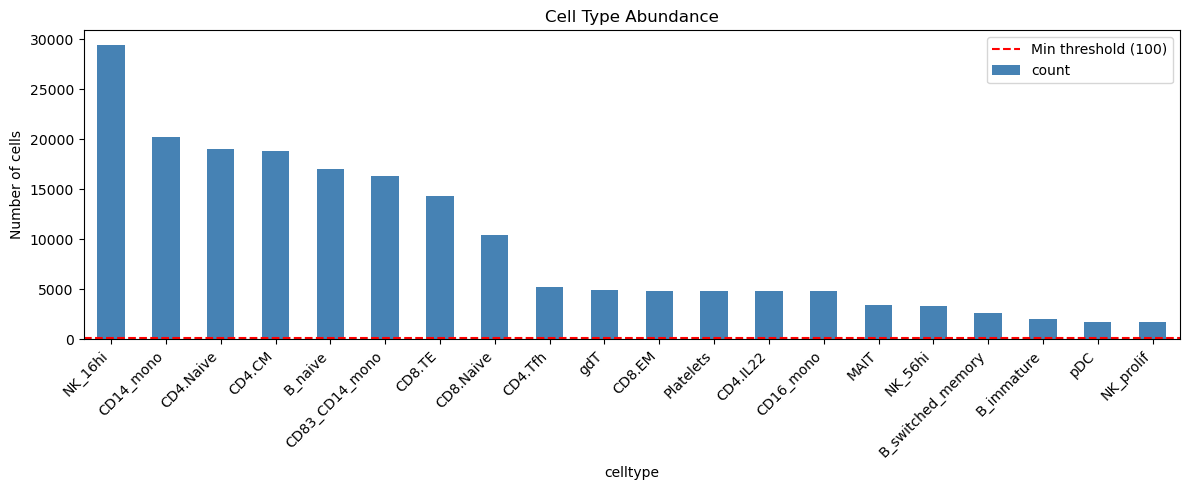

In [8]:
# Cell type counts
ct_counts = adata.obs["celltype"].value_counts()
print(f"Total cell types: {len(ct_counts)}")

# Filter to well-represented types
valid_celltypes = ct_counts[ct_counts >= MIN_CELLS_PER_CELLTYPE].index.tolist()
print(f"Cell types with ≥{MIN_CELLS_PER_CELLTYPE} cells: {len(valid_celltypes)}")

# Show top cell types
print("\nTop 15 cell types:")
display(ct_counts.head(15).to_frame("n_cells"))

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
ct_counts.head(20).plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(MIN_CELLS_PER_CELLTYPE, color="red", linestyle="--", label=f"Min threshold ({MIN_CELLS_PER_CELLTYPE})")
ax.set_title("Cell Type Abundance")
ax.set_ylabel("Number of cells")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. UMAP Visualization


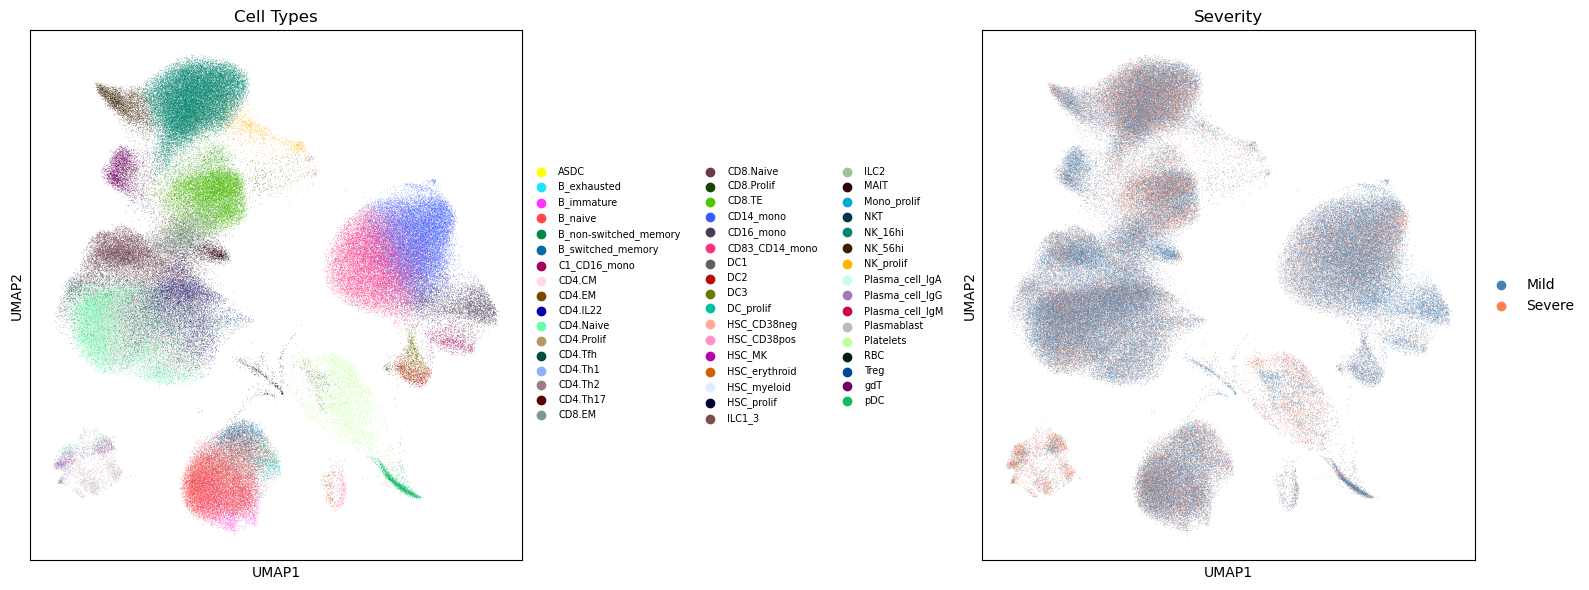

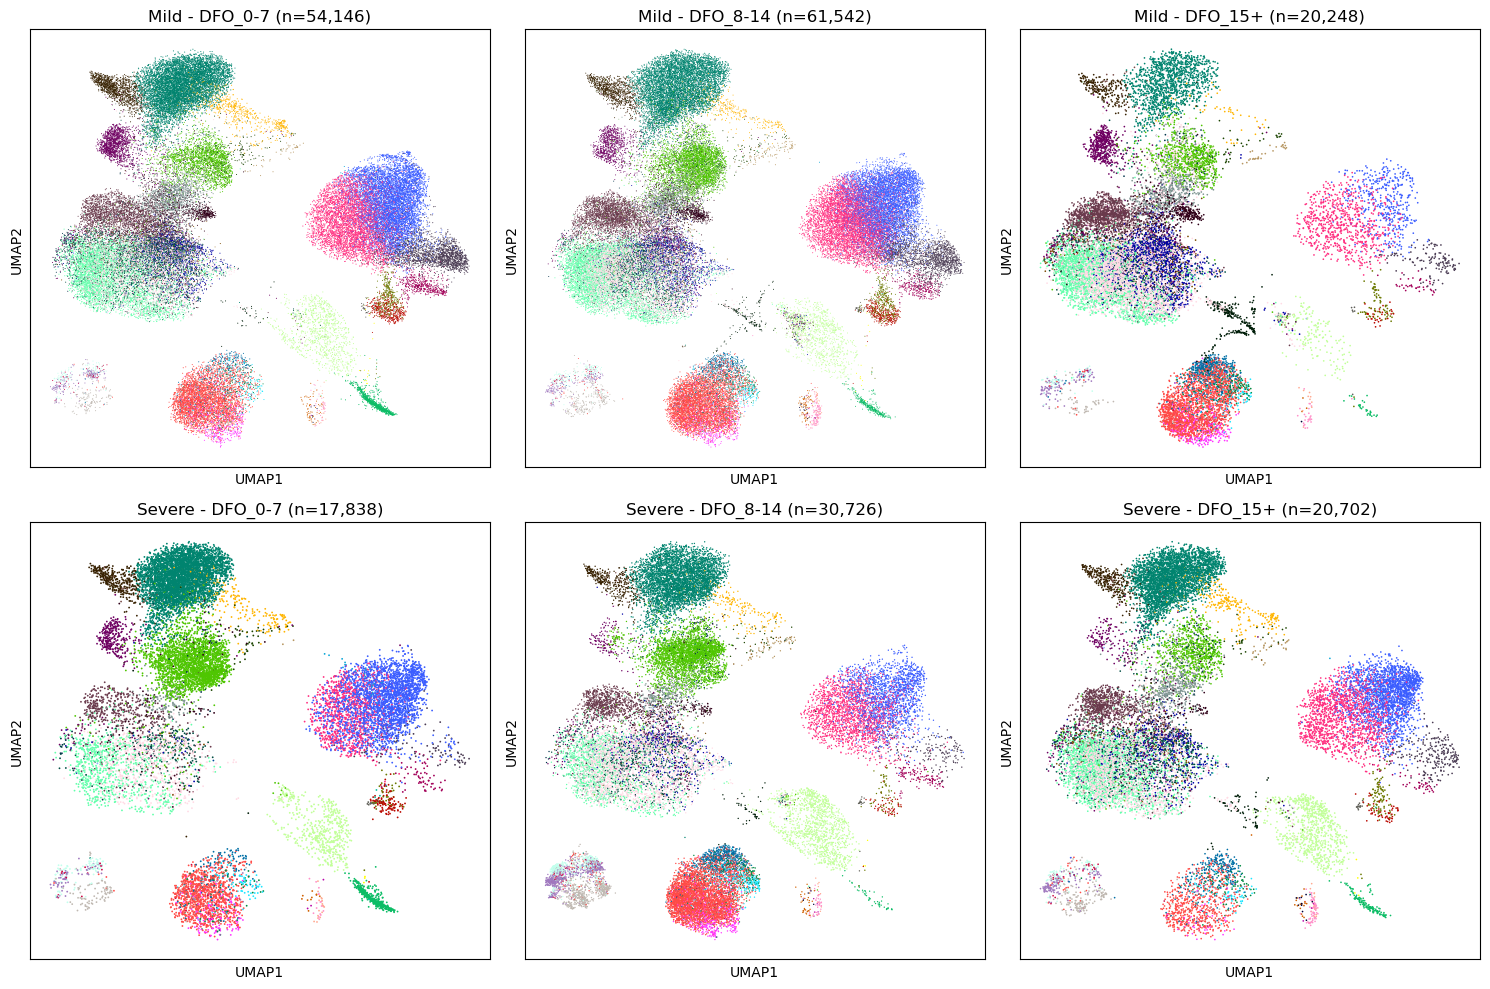

In [9]:
# Compute UMAP if missing
if "X_umap" not in adata.obsm:
    print("Computing UMAP...")
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

# Global UMAP colored by cell type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(adata, color="celltype", ax=axes[0], show=False,
           legend_loc="right margin", legend_fontsize=7, title="Cell Types")
sc.pl.umap(adata, color="severity", ax=axes[1], show=False,
           palette=["steelblue", "coral"], title="Severity")

plt.tight_layout()
plt.show()

# UMAP by severity and DFO
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, severity in enumerate(["Mild", "Severe"]):
    for j, dfo in enumerate(["DFO_0-7", "DFO_8-14", "DFO_15+"]):
        ax = axes[i, j]
        mask = (adata.obs["severity"] == severity) & (adata.obs["dfo_bin"] == dfo)
        if mask.sum() > 0:
            sub = adata[mask].copy()
            sc.pl.umap(sub, color="celltype", ax=ax, show=False,
                      legend_loc="none", title=f"{severity} - {dfo} (n={mask.sum():,})")
        else:
            ax.set_title(f"{severity} - {dfo} (no cells)")
            ax.axis("off")

plt.tight_layout()
plt.show()

## 7. COVID-19 Immune Signatures

We define biologically relevant gene signatures for COVID-19 immune profiling, including:
- **Interferon response**: Key antiviral pathway, often elevated in severe disease
- **Inflammation**: S100 alarmins and cytokines associated with cytokine storm
- **Cytotoxicity**: NK/CD8 T cell function, important for viral clearance
- **T cell exhaustion**: Dysfunction markers elevated in severe/prolonged infection
- **Myeloid activation**: Monocyte/macrophage markers, drivers of pathology


In [10]:
available_genes = set(adata.var_names)

# COVID-19 relevant gene signatures
gene_signatures = {
    "IFN_Response": [
        "ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3", "MX1", "MX2", 
        "STAT1", "STAT2", "OAS1", "OAS2", "OAS3", "IRF7", "IFITM1", "IFITM3"
    ],
    "Inflammation": [
        "S100A8", "S100A9", "S100A12", "LYZ", "VCAN", "IL1B", 
        "CXCL8", "TNF", "NFKBIA", "CCL2", "CCL3", "CCL4"
    ],
    "Cytotoxicity": [
        "GZMB", "GZMA", "GZMH", "GZMK", "PRF1", "GNLY", "NKG7", 
        "KLRD1", "KLRB1", "IFNG"
    ],
    "T_Cell_Exhaustion": [
        "PDCD1", "LAG3", "HAVCR2", "TIGIT", "CTLA4", "TOX", "ENTPD1"
    ],
    "Myeloid_Activation": [
        "CD14", "FCGR3A", "CD68", "MARCO", "MSR1", "CD163", 
        "CTSS", "CST3", "LGALS3", "AIF1"
    ],
    "B_Cell_Activation": [
        "MS4A1", "CD19", "CD79A", "CD79B", "BANK1", "CD74", 
        "HLA-DRA", "HLA-DRB1", "IGHM", "IGHG1"
    ],
}

# Filter to available genes and report coverage
print("Gene signature coverage:")
print("-" * 50)
filtered_signatures = {}
for name, genes in gene_signatures.items():
    found = [g for g in genes if g in available_genes]
    pct = len(found) / len(genes) * 100
    print(f"{name}: {len(found)}/{len(genes)} genes ({pct:.0f}%)")
    if len(found) >= MIN_GENES_FOR_SCORE:
        filtered_signatures[name] = found
    else:
        print(f"  ⚠️  Skipping (need ≥{MIN_GENES_FOR_SCORE} genes)")

# Score gene sets using z-mean method (accounts for different expression scales)
if filtered_signatures:
    adata = st.score_gene_sets(
        adata, 
        filtered_signatures, 
        layer="log1p_cpm", 
        method="zmean",  # Z-score normalization for fair weighting
        prefix="sig_"
    )
    print(f"\n✓ Scored {len(filtered_signatures)} signatures")

# Get signature columns
signature_cols = [c for c in adata.obs.columns if c.startswith("sig_")]
print(f"\nSignature scores available: {signature_cols}")

Gene signature coverage:
--------------------------------------------------
IFN_Response: 15/15 genes (100%)
Inflammation: 12/12 genes (100%)
Cytotoxicity: 10/10 genes (100%)
T_Cell_Exhaustion: 7/7 genes (100%)
Myeloid_Activation: 10/10 genes (100%)
B_Cell_Activation: 10/10 genes (100%)



✓ Scored 6 signatures

Signature scores available: ['sig_IFN_Response', 'sig_Inflammation', 'sig_Cytotoxicity', 'sig_T_Cell_Exhaustion', 'sig_Myeloid_Activation', 'sig_B_Cell_Activation']


## 8. Cross-Sectional Comparisons: Severity Differences at Each Timepoint

This is the primary analysis. We compare immune signatures between Mild and Severe patients at each DFO timepoint, using:
- Participant-level aggregation (to avoid pseudoreplication)
- Cell-type adjustment (to account for compositional differences)
- FDR correction for multiple testing


In [11]:
# Run comparisons at each timepoint using sctrial's built-in function
# This properly aggregates to participant level and handles the statistics correctly
print("="*60)
print("CROSS-SECTIONAL ANALYSIS: Severe vs Mild at each DFO bin")
print("="*60)
print("\nPositive beta = higher in Severe; Negative beta = higher in Mild")
print("Using participant-level aggregation to avoid pseudoreplication\n")

# Use a lower threshold (3) to include more timepoints for exploratory analysis
MIN_CROSS_SECTIONAL = 3

all_results = []
for visit in available_visits:
    print(f"\n{visit}:")
    
    # Check sample size first
    ad_visit = adata[adata.obs["dfo_bin"] == visit]
    n_per_group = ad_visit.obs.groupby("severity")["participant_id"].nunique()
    n_min = n_per_group.min()
    
    if n_min < MIN_CROSS_SECTIONAL:
        print(f"  Skipped: Insufficient participants (Mild={n_per_group.get('Mild', 0)}, Severe={n_per_group.get('Severe', 0)})")
        continue
    
    if n_min < MIN_PARTICIPANTS_FOR_COMPARISON:
        print(f"  Note: Small sample (Mild={n_per_group.get('Mild', 0)}, Severe={n_per_group.get('Severe', 0)}) — interpret with caution")
    
    # Use sctrial's built-in between_arm_comparison
    # This properly aggregates to participant level
    res = st.between_arm_comparison(
        adata,
        visit=visit,
        features=signature_cols,
        design=design,
        aggregate="participant_visit",
        standardize=True,
        method="ols",
    )
    
    if not res.empty:
        # Rename columns for consistency
        res = res.rename(columns={"beta_arm": "beta", "p_arm": "p_value", "FDR_arm": "fdr"})
        res["timepoint"] = visit
        all_results.append(res)
        
        # Display results
        display_cols = ["feature", "beta", "p_value", "fdr", "n_units"]
        display(res[display_cols].round(4))
        
        # Highlight significant
        sig = res[res["fdr"] < FDR_ALPHA]
        if not sig.empty:
            print(f"  Significant (FDR<{FDR_ALPHA}): {sig['feature'].tolist()}")

# Combine results
if all_results:
    combined_results = pd.concat(all_results, ignore_index=True)
else:
    combined_results = pd.DataFrame()

CROSS-SECTIONAL ANALYSIS: Severe vs Mild at each DFO bin

Positive beta = higher in Severe; Negative beta = higher in Mild
Using participant-level aggregation to avoid pseudoreplication


DFO_0-7:
  Skipped: Insufficient participants (Mild=8, Severe=2)

DFO_15+:
  Note: Small sample (Mild=4, Severe=4) — interpret with caution


,feature,beta,p_value,fdr,n_units
0,sig_IFN_Response,0.4732,0.5456,0.6547,8
1,sig_Inflammation,1.3433,0.0449,0.2692,8
2,sig_Cytotoxicity,0.6567,0.3939,0.6136,8
3,sig_T_Cell_Exhaustion,0.2095,0.7917,0.7917,8
4,sig_Myeloid_Activation,0.6372,0.4091,0.6136,8
5,sig_B_Cell_Activation,-1.0558,0.1451,0.4352,8



DFO_8-14:


,feature,beta,p_value,fdr,n_units
0,sig_IFN_Response,-0.0684,0.9042,0.9712,16
1,sig_Inflammation,-0.0576,0.9192,0.9712,16
2,sig_Cytotoxicity,0.1428,0.8014,0.9712,16
3,sig_T_Cell_Exhaustion,0.7136,0.1953,0.5860,16
4,sig_Myeloid_Activation,0.0205,0.9712,0.9712,16
5,sig_B_Cell_Activation,1.0750,0.0414,0.2483,16


  Significant (FDR<0.25): ['sig_B_Cell_Activation']


### 6.1 Adjusted Cross-Sectional Comparisons

In [12]:
# Adjusted cross-sectional analysis (includes covariates)
print('\nAdjusted cross-sectional analysis (covariates):', covariates_adj)
cross_sectional_adj = []
features_adj = signature_cols
visits_adj = tuple(sorted(
    adata.obs[design.visit_col].dropna().unique(),
    key=lambda c: int(c.split('_')[1].split('-')[0].rstrip('+')),
)[:2])
if features_adj:
    for v in visits_adj:
        print(f'\nAdjusted results at visit: {v}')
        res = st.between_arm_comparison(
            adata,
            visit=v,
            features=features_adj,
            design=design,
            aggregate='participant_visit',
            standardize=True,
            method='ols',
            covariates=covariates_adj if covariates_adj else None,
        )
        if res is not None and not res.empty:
            res['visit'] = v
            cross_sectional_adj.append(res)
            display(res[['feature', 'beta_arm', 'p_arm', 'FDR_arm', 'n_units']].round(4))
if cross_sectional_adj:
    all_cross_adj = __import__('pandas').concat(cross_sectional_adj, ignore_index=True)
else:
    all_cross_adj = __import__('pandas').DataFrame()



Adjusted cross-sectional analysis (covariates): ['Age_interval', 'Sex', 'Site']

Adjusted results at visit: DFO_0-7


,feature,beta_arm,p_arm,FDR_arm,n_units
0,sig_IFN_Response,0.0000,0.9999,0.9999,10
1,sig_Inflammation,-0.6617,0.5035,0.7553,10
2,sig_Cytotoxicity,1.5344,0.3092,0.7016,10
3,sig_T_Cell_Exhaustion,0.0728,0.9344,0.9999,10
4,sig_Myeloid_Activation,-0.8469,0.2063,0.7016,10
5,sig_B_Cell_Activation,-1.4705,0.3508,0.7016,10



Adjusted results at visit: DFO_8-14


,feature,beta_arm,p_arm,FDR_arm,n_units
0,sig_IFN_Response,-0.3551,0.4643,0.8604,16
1,sig_Inflammation,0.0796,0.8381,0.8604,16
2,sig_Cytotoxicity,-0.1519,0.8604,0.8604,16
3,sig_T_Cell_Exhaustion,0.4013,0.5100,0.8604,16
4,sig_Myeloid_Activation,0.0866,0.8155,0.8604,16
5,sig_B_Cell_Activation,0.9085,0.2525,0.8604,16


## 9. Visualization of Severity Differences


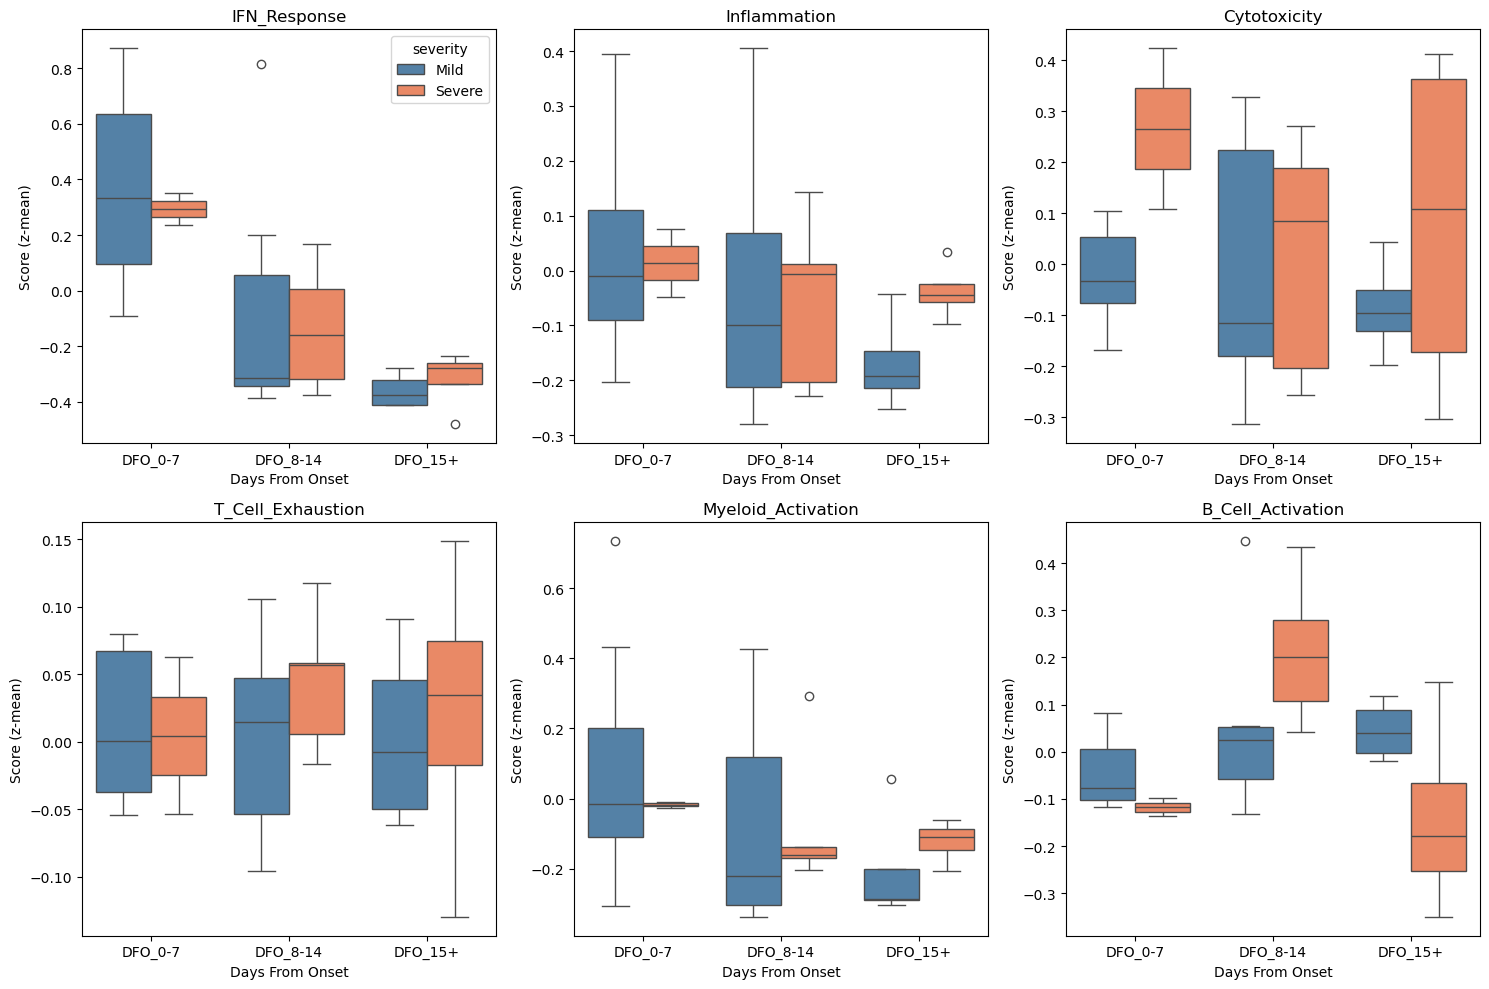

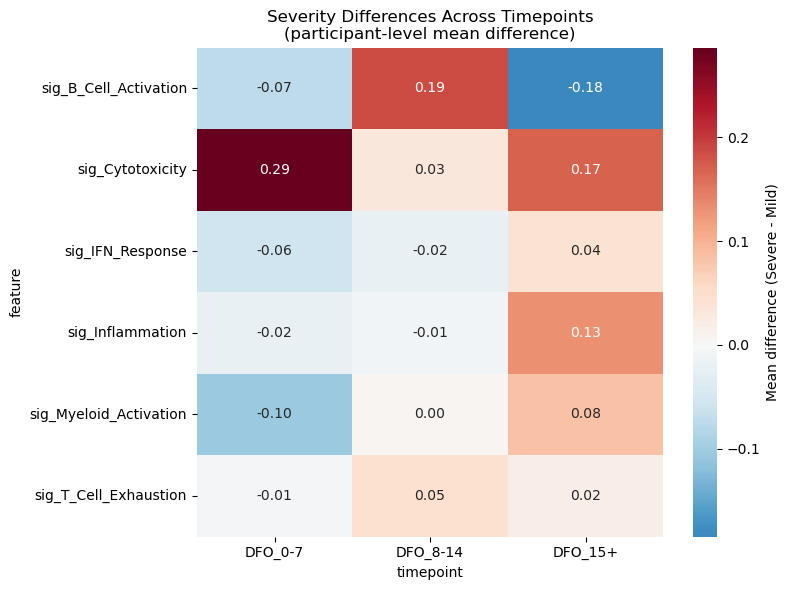

In [13]:
# Visualize signature distributions by severity and timepoint
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, sig in enumerate(signature_cols[:6]):
    ax = axes.flat[i]

    # Aggregate to participant level for cleaner visualization
    df_plot = (
        adata.obs
        .groupby(["participant_id", "severity", "dfo_bin"], observed=True)[sig]
        .mean()
        .reset_index()
    )

    sns.boxplot(
        data=df_plot, x="dfo_bin", y=sig, hue="severity",
        palette={"Mild": "steelblue", "Severe": "coral"},
        ax=ax
    )
    ax.set_title(sig.replace("sig_", ""))
    ax.set_xlabel("Days From Onset")
    ax.set_ylabel("Score (z-mean)")
    if i > 0:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

# Heatmap of effect sizes across ALL visits (computed directly from participant means)
# Uses a lower threshold (≥2 per group) for visualization purposes
heatmap_rows = []
for visit in available_visits:
    ad_v = adata[adata.obs["dfo_bin"] == visit]
    df_agg = (
        ad_v.obs
        .groupby(["participant_id", "severity"], observed=True)[signature_cols]
        .mean()
        .reset_index()
    )
    n_mild = (df_agg["severity"] == "Mild").sum()
    n_severe = (df_agg["severity"] == "Severe").sum()
    if min(n_mild, n_severe) < 2:
        continue
    for sig in signature_cols:
        mild_vals = df_agg.loc[df_agg["severity"] == "Mild", sig].values
        severe_vals = df_agg.loc[df_agg["severity"] == "Severe", sig].values
        diff = severe_vals.mean() - mild_vals.mean()
        heatmap_rows.append({"feature": sig, "timepoint": visit, "diff": diff})

if heatmap_rows:
    df_heatmap = pd.DataFrame(heatmap_rows)
    pivot = df_heatmap.pivot(index="feature", columns="timepoint", values="diff")
    # Sort columns chronologically (alphabetical puts DFO_15-27 before DFO_8-14)
    pivot = pivot[sorted(pivot.columns, key=lambda c: int(c.split("_")[1].split("-")[0].rstrip("+")))]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        pivot, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
        cbar_kws={"label": "Mean difference (Severe - Mild)"}
    )
    plt.title("Severity Differences Across Timepoints\n(participant-level mean difference)")
    plt.tight_layout()
    plt.show()
elif not combined_results.empty:
    pivot = combined_results.pivot(index="feature", columns="timepoint", values="beta")
    pivot = pivot[sorted(pivot.columns, key=lambda c: int(c.split("_")[1].split("-")[0].rstrip("+")))]
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        pivot, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
        cbar_kws={"label": "Effect size (Severe - Mild)"}
    )
    plt.title("Severity Effect Sizes Across Timepoints")
    plt.tight_layout()
    plt.show()

## 10. Cell-Type Specific Analysis

Examine severity differences within specific immune cell populations.


In [14]:
# Focus on major immune populations
# Map fine cell types to major lineages for robust analysis
adata.obs["lineage"] = adata.obs["celltype"].apply(categorize_celltype)
print("Lineage distribution:")
print(adata.obs["lineage"].value_counts())

focus_lineages = ["CD4_T", "CD8_T", "Monocytes", "NK"]

# Auto-select the visit with the best participant balance across arms
visit_scores = []
for v in sorted(adata.obs["dfo_bin"].dropna().unique()):
    sub = adata.obs[adata.obs["dfo_bin"] == v]
    counts = sub.groupby("severity")["participant_id"].nunique()
    n_mild = int(counts.get("Mild", 0))
    n_severe = int(counts.get("Severe", 0))
    visit_scores.append((v, n_mild, n_severe, min(n_mild, n_severe)))
visit_scores.sort(key=lambda x: (x[3], x[1] + x[2]), reverse=True)
focus_visit = visit_scores[0][0]

print(f"\n=== Cell-Type Specific Analysis at {focus_visit} ===")
print(f"    (auto-selected: best participant balance across arms)")

# Use sctrial between_arm_comparison per lineage
lineage_results = []
for lineage in focus_lineages:
    ad_sub = adata[(adata.obs["lineage"] == lineage) & (adata.obs["dfo_bin"] == focus_visit)].copy()
    if ad_sub.n_obs < 100:
        print(f"{lineage}: Insufficient cells ({ad_sub.n_obs})")
        continue
    n_per_group = ad_sub.obs.groupby("severity")["participant_id"].nunique()
    if n_per_group.min() < 3:
        print(f"{lineage}: Insufficient participants")
        continue
    print(f"{lineage} (n={ad_sub.n_obs:,} cells, {n_per_group.sum()} participants):")

    res = st.between_arm_comparison(
        ad_sub,
        visit=focus_visit,
        features=signature_cols[:4],
        design=design,
        method="wilcoxon",
    )
    res["lineage"] = lineage
    lineage_results.append(res)

if lineage_results:
    df_lineage = pd.concat(lineage_results, ignore_index=True)
    print("\nResults (participant-level Mann-Whitney U via sctrial):")
    display(df_lineage[["lineage", "feature", "beta", "p", "FDR"]].round(4))

    # Pivot for heatmap
    pivot = df_lineage.pivot(index="feature", columns="lineage", values="beta")
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, cmap="RdBu_r", center=0, annot=True, fmt=".2f")
    plt.title(f"Severity Effect by Cell Type ({focus_visit})")
    plt.tight_layout()
    plt.show()


## 11. Cell Type Abundance Differences

Compare cell type composition between severity groups.


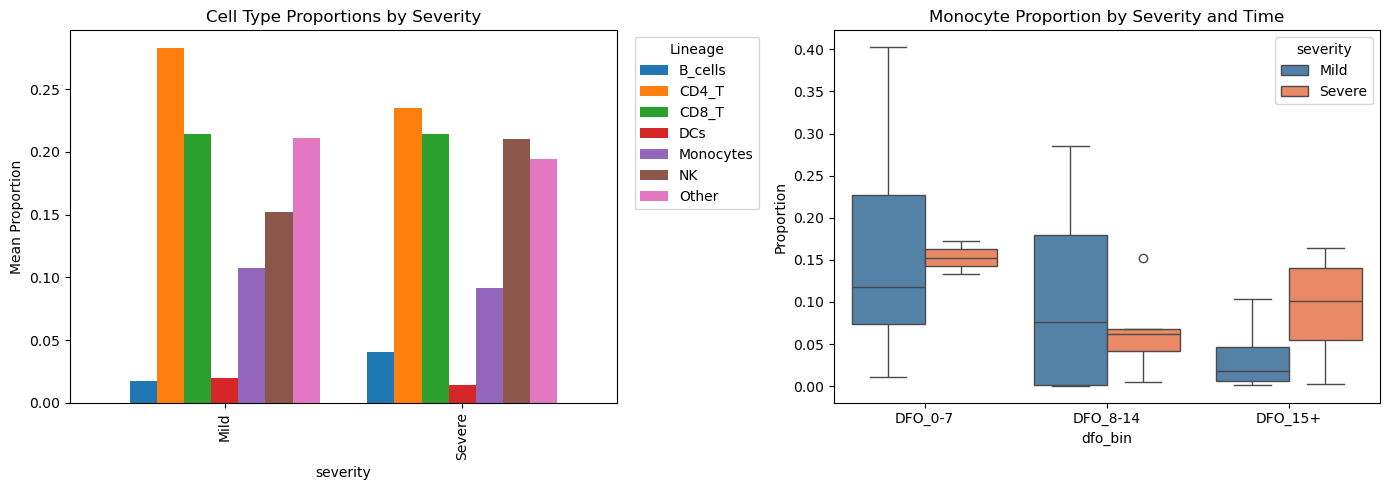


Abundance differences (Severe vs Mild) at DFO 0-7:
Note: Each data point = one participant's cell type proportion
--------------------------------------------------


In [15]:
# Calculate cell type proportions per participant
# Note: Each row in 'props' after grouping is one participant-visit-lineage combination
# When we test, each participant contributes ONE proportion value per lineage
props = (
    adata.obs
    .groupby(["participant_id", "severity", "dfo_bin", "lineage"], observed=True)
    .size()
    .reset_index(name="n")
)
totals = props.groupby(["participant_id", "dfo_bin"])["n"].transform("sum")
props["proportion"] = props["n"] / totals

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By severity
props_by_sev = props.groupby(["severity", "lineage"])["proportion"].mean().unstack()
props_by_sev.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Cell Type Proportions by Severity")
axes[0].set_ylabel("Mean Proportion")
axes[0].legend(title="Lineage", bbox_to_anchor=(1.02, 1))

# Monocyte proportion over time
mono_props = props[props["lineage"] == "Monocytes"].copy()
sns.boxplot(data=mono_props, x="dfo_bin", y="proportion", hue="severity",
            palette={"Mild": "steelblue", "Severe": "coral"}, ax=axes[1])
axes[1].set_title("Monocyte Proportion by Severity and Time")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

# Statistical test for abundance differences
# CORRECT: Each observation in props_early is already at participant level
# so Mann-Whitney U is appropriate here (no pseudoreplication)
print("\nAbundance differences (Severe vs Mild) at DFO 0-7:")
print("Note: Each data point = one participant's cell type proportion")
print("-" * 50)

props_early = props[props["dfo_bin"] == "DFO_0-7"]
abundance_results = []
for lineage in ["Monocytes", "CD8_T", "NK", "B_cells"]:
    sub = props_early[props_early["lineage"] == lineage]
    mild = sub.loc[sub["severity"] == "Mild", "proportion"]
    severe = sub.loc[sub["severity"] == "Severe", "proportion"]
    
    if len(mild) >= 3 and len(severe) >= 3:
        stat, pval = mannwhitneyu(mild, severe, alternative="two-sided")
        diff = severe.mean() - mild.mean()
        abundance_results.append({
            "lineage": lineage,
            "diff": diff,
            "p_value": pval,
            "n_mild": len(mild),
            "n_severe": len(severe),
        })
        print(f"{lineage}: diff={diff:+.3f}, p={pval:.4f} (n_mild={len(mild)}, n_severe={len(severe)})")

if abundance_results:
    df_abund = pd.DataFrame(abundance_results)
    df_abund["fdr"] = multipletests(df_abund["p_value"], method="fdr_bh")[1]
    print(f"\nFDR-corrected results:")
    display(df_abund.round(4))

### 9.1 Adjusted Abundance DiD


Adjusted abundance DiD (covariates): ['Age_interval', 'Sex', 'Site']
Adjusted abundance covariates: ['age_mid', 'Sex', 'Site']
Participant counts per cell type (treated/control):


severity,Mild,Severe
celltype,,
ASDC,13,4
B_exhausted,19,7
B_immature,19,7
B_naive,19,7
B_non-switched_memory,19,7
B_switched_memory,19,7
C1_CD16_mono,11,5
CD4.CM,19,7
CD4.EM,19,7


Attempt: full covariates -> ['age_mid', 'Sex', 'Site']


Attempt: numeric-only covariates -> ['age_mid']


Attempt: unadjusted fallback covariates -> []


No adjusted abundance DiD results after retries.
No paired participants for abundance DiD. Running baseline cross-sectional abundance instead.


,celltype,n_participants,beta_arm,p_arm,FDR_arm
21,DC1,7,0.001090,0.032445,0.781814
11,CD4.IL22,10,-0.007421,0.044069,0.781814
36,NK_16hi,10,0.075020,0.055844,0.781814
23,DC3,10,-0.001242,0.143460,0.875708
35,NKT,10,0.002001,0.147275,0.875708
19,CD8.TE,10,0.130125,0.165944,0.875708
2,B_immature,10,-0.005815,0.167006,0.875708
1,B_exhausted,10,0.001560,0.173708,0.875708
28,HSC_erythroid,9,-0.000836,0.218194,0.875708
6,C1_CD16_mono,8,-0.010052,0.234704,0.875708


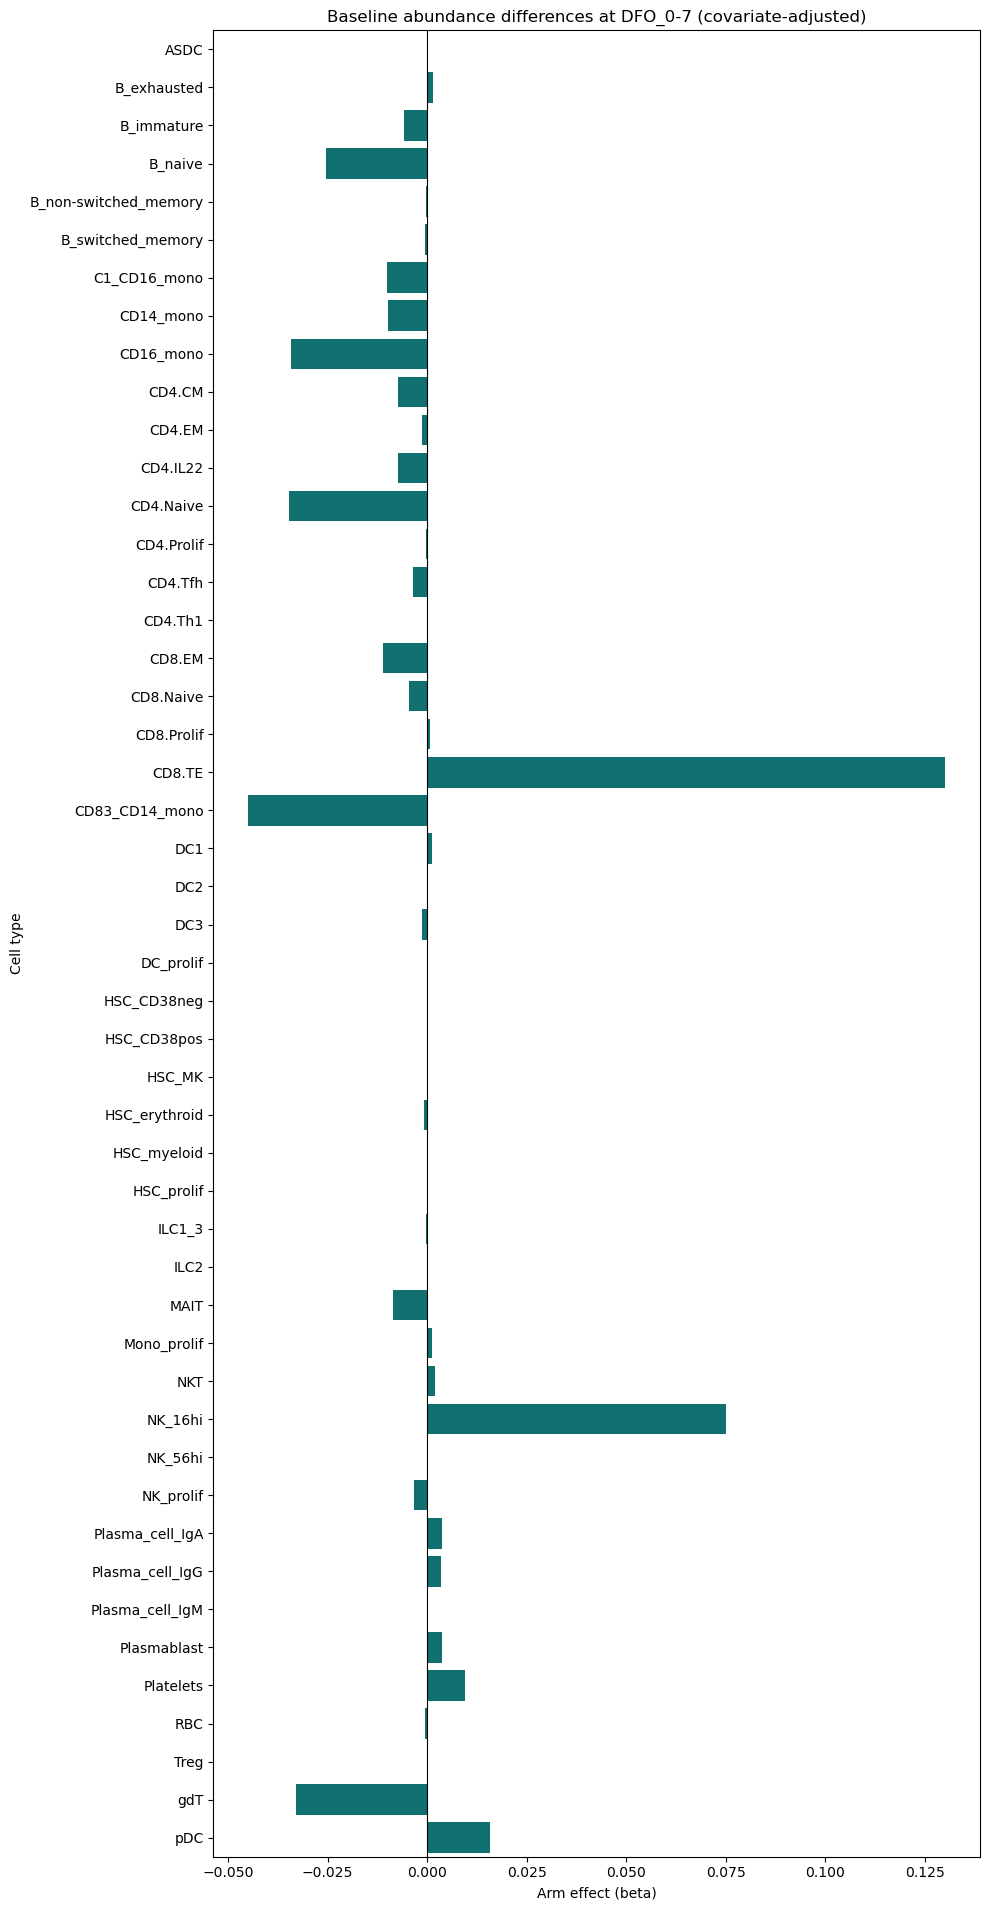

In [16]:
# Adjusted abundance DiD (covariates)
print('\nAdjusted abundance DiD (covariates):', covariates_adj)
# Build numeric covariates for abundance models when possible
covariates_ab = []
if 'Age_interval' in adata.obs.columns:
    # Convert intervals like '(50, 59]' to midpoint
    def _age_mid(x):
        try:
            s = str(x).strip().strip('()[]')
            lo, hi = s.split(',')
            return (float(lo) + float(hi)) / 2
        except Exception:
            return float('nan')
    adata.obs['age_mid'] = adata.obs['Age_interval'].map(_age_mid)
    if adata.obs['age_mid'].notna().any():
        covariates_ab.append('age_mid')
if 'Sex' in adata.obs.columns:
    covariates_ab.append('Sex')
if 'Site' in adata.obs.columns:
    # high-cardinality sites can destabilize models; include only if <=3 levels
    if adata.obs['Site'].nunique() <= 3:
        covariates_ab.append('Site')
print('Adjusted abundance covariates:', covariates_ab)

if design.celltype_col:
    # Diagnostic: participant counts per celltype at selected visits
    visits_ab = sorted(
        adata.obs[design.visit_col].dropna().unique(),
        key=lambda c: int(c.split('_')[1].split('-')[0].rstrip('+')),
    )[:2]
    diag = (
        adata.obs[adata.obs[design.visit_col].isin(visits_ab)]
        .groupby([design.celltype_col, design.arm_col])[design.participant_col]
        .nunique()
        .unstack(fill_value=0)
    )
    print('Participant counts per cell type (treated/control):')
    display(diag)

    def _run_ab(covs, label):
        print(f'Attempt: {label} covariates -> {covs}')
        return st.abundance_did(
            adata,
            design,
            visits=tuple(visits_ab),
            covariates=covs if covs else None,
            min_units=3,
            use_bootstrap=True,
            n_boot=199,
            seed=SEED,
        )

    ab_adj = _run_ab(covariates_ab, 'full')
    if ab_adj is None or ab_adj.empty:
        # retry with numeric-only covariates
        num_covs = [c for c in covariates_ab if c == 'age_mid']
        ab_adj = _run_ab(num_covs, 'numeric-only')
    if ab_adj is None or ab_adj.empty:
        # final fallback: unadjusted
        ab_adj = _run_ab([], 'unadjusted fallback')

    if ab_adj is not None and not ab_adj.empty:
        display(ab_adj.round(4))
        try:
            plt.figure(figsize=(10, max(3, 0.4 * len(ab_adj))))
            sns.barplot(data=ab_adj, y='celltype', x='beta_DiD', color='teal')
            plt.axvline(0, color='black', linewidth=0.8)
            plt.title('Adjusted Abundance DiD (covariates)')
            plt.xlabel('DiD effect (beta)')
            plt.ylabel('Cell type')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'Adjusted abundance plot failed: {e}')
    else:
        print('No adjusted abundance DiD results after retries.')


    # If DiD is not feasible (no paired participants), run cross-sectional abundance at baseline
    if ab_adj is None or ab_adj.empty:
        # Check paired participants overall
        visits_use = tuple(visits_ab)
        obs_use = adata.obs[adata.obs[design.visit_col].isin(visits_use)].copy()
        totals_all = (
            obs_use.groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)
            .size()
            .reset_index(name='n_cells')
        )
        wide_tot = totals_all.pivot_table(
            index=design.participant_col,
            columns=design.visit_col,
            values='n_cells',
            aggfunc='mean',
            observed=True,
        )
        paired_units = wide_tot[wide_tot[visits_use[0]].notna() & wide_tot[visits_use[1]].notna()].index
        if len(paired_units) == 0:
            print('No paired participants for abundance DiD. Running baseline cross-sectional abundance instead.')
            baseline_visit = visits_use[0]
            obs_base = adata.obs[adata.obs[design.visit_col] == baseline_visit].copy()
            # proportions per participant × celltype
            counts_base = (
                obs_base.groupby([design.participant_col, design.arm_col, design.celltype_col], observed=True)
                .size()
                .reset_index(name='n_cells')
            )
            totals_base = (
                counts_base.groupby([design.participant_col, design.arm_col], observed=True)['n_cells']
                .sum()
                .reset_index(name='total_cells')
            )
            counts_base = counts_base.merge(totals_base, on=[design.participant_col, design.arm_col], how='left')
            counts_base['prop'] = counts_base['n_cells'] / counts_base['total_cells'].clip(lower=1)

            # attach covariates (participant-level)
            cov_df = obs_base[[design.participant_col] + covariates_ab].drop_duplicates()
            counts_base = counts_base.merge(cov_df, on=design.participant_col, how='left')
            counts_base['arm_bin'] = design.arm_bin(counts_base)
            counts_base = counts_base.dropna(subset=['arm_bin'])

            rows = []
            for ct in sorted(counts_base[design.celltype_col].unique()):
                tmp = counts_base[counts_base[design.celltype_col] == ct].copy()
                if tmp[design.participant_col].nunique() < 3:
                    continue
                if tmp['prop'].nunique() < 2:
                    continue
                formula = 'prop ~ arm_bin'
                if covariates_ab:
                    formula += ' + ' + ' + '.join(covariates_ab)
                import statsmodels.formula.api as smf
                fit = smf.ols(formula, data=tmp).fit()
                if 'arm_bin' not in fit.params or fit.params['arm_bin'] is None:
                    continue
                rows.append({
                    'celltype': ct,
                    'n_participants': int(tmp[design.participant_col].nunique()),
                    'beta_arm': float(fit.params['arm_bin']),
                    'p_arm': float(fit.pvalues['arm_bin']),
                })
            if rows:
                import pandas as pd
                from statsmodels.stats.multitest import multipletests
                res_xs = pd.DataFrame(rows)
                mask = res_xs['p_arm'].notna()
                res_xs['FDR_arm'] = pd.NA
                if mask.any():
                    res_xs.loc[mask, 'FDR_arm'] = multipletests(res_xs.loc[mask,'p_arm'], method='fdr_bh')[1]
                display(res_xs.sort_values('p_arm').head(20))
                try:
                    plt.figure(figsize=(10, max(3, 0.4 * len(res_xs))))
                    sns.barplot(data=res_xs, y='celltype', x='beta_arm', color='teal')
                    plt.axvline(0, color='black', linewidth=0.8)
                    plt.title(f'Baseline abundance differences at {baseline_visit} (covariate-adjusted)')
                    plt.xlabel('Arm effect (beta)')
                    plt.ylabel('Cell type')
                    plt.tight_layout()
                    plt.show()
                except Exception as e:
                    print(f'Baseline abundance plot failed: {e}')


## 12. Individual Gene Analysis

Examine specific genes of interest for COVID-19.


Analyzing 12 COVID-relevant genes


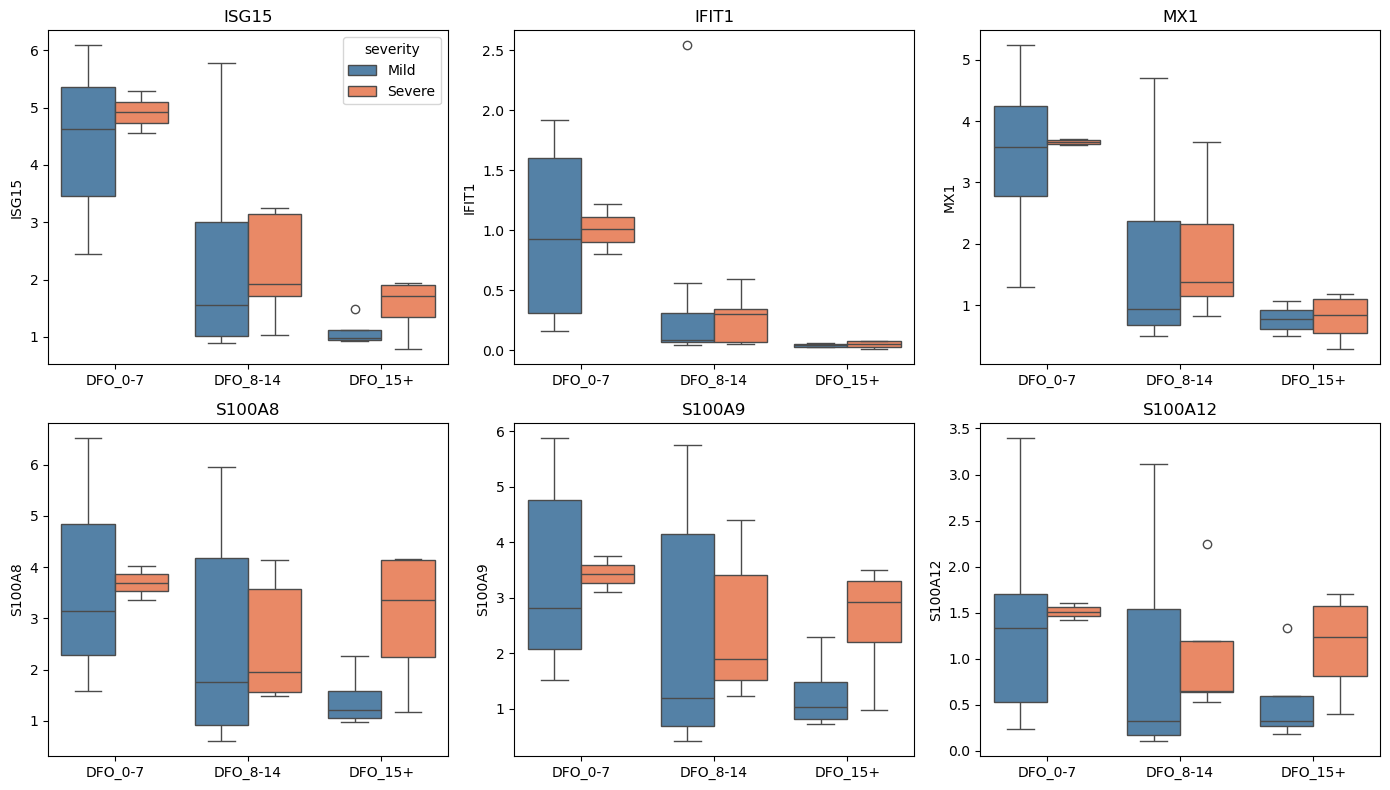

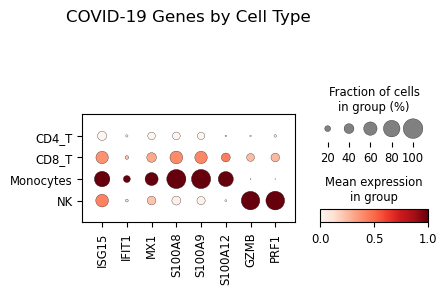

In [17]:
# Key COVID-19 genes
covid_genes = [
    "ISG15", "IFIT1", "MX1",       # IFN response
    "S100A8", "S100A9", "S100A12",  # Alarmins
    "GZMB", "PRF1", "NKG7",         # Cytotoxicity  
    "IL1B", "TNF", "CXCL8",         # Cytokines
]
covid_genes = [g for g in covid_genes if g in adata.var_names]
print(f"Analyzing {len(covid_genes)} COVID-relevant genes")

# Extract expression for visualization
gene_expr = pd.DataFrame(
    adata[:, covid_genes].layers["log1p_cpm"].toarray() if sp.issparse(adata[:, covid_genes].layers["log1p_cpm"]) 
    else adata[:, covid_genes].layers["log1p_cpm"],
    columns=covid_genes,
    index=adata.obs_names
)
gene_expr = gene_expr.join(adata.obs[["severity", "dfo_bin", "participant_id", "lineage"]])

# Aggregate to participant level
gene_means = gene_expr.groupby(["participant_id", "severity", "dfo_bin"])[covid_genes].mean().reset_index()

# Visualize key genes
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, gene in enumerate(covid_genes[:6]):
    ax = axes.flat[i]
    sns.boxplot(
        data=gene_means, x="dfo_bin", y=gene, hue="severity",
        palette={"Mild": "steelblue", "Severe": "coral"}, ax=ax
    )
    ax.set_title(gene)
    ax.set_xlabel("")
    if i > 0:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

# Dotplot of genes by cell type
if len(covid_genes) > 0:
    adata_dot = adata[adata.obs["lineage"].isin(["Monocytes", "CD8_T", "NK", "CD4_T"])].copy()
    sc.pl.dotplot(
        adata_dot,
        var_names=covid_genes[:8],
        groupby="lineage",
        standard_scale="var",
        title="COVID-19 Genes by Cell Type"
    )

## 13. Advanced Statistical Analyses

Statistical tools for cross-sectional observational data:
- **Effect sizes**: Cohen's d for severity group comparisons
- **Power analysis**: Sample size planning for future studies
- **Effective sample size**: Understanding clustering effects


### 13.1 Effect Sizes for Cross-Sectional Comparisons

Effect sizes quantify the magnitude of differences between Mild and Severe cases.


EFFECT SIZE ANALYSIS (Cross-Sectional)



Effect sizes (Severe vs Mild):
  Positive = higher in Severe, Negative = higher in Mild



,timepoint,feature,cohens_d,hedges_g,ci_lower,ci_upper,n_mild,n_severe
0,DFO_15+,sig_IFN_Response,0.453,0.393,-0.730,4.212,4,4
1,DFO_15+,sig_Inflammation,1.787,1.552,0.527,5.782,4,4
2,DFO_15+,sig_Cytotoxicity,0.649,0.564,-1.608,5.717,4,4
3,DFO_15+,sig_T_Cell_Exhaustion,0.195,0.170,-1.177,2.273,4,4
4,DFO_15+,sig_Myeloid_Activation,0.627,0.545,-0.630,12.730,4,4
5,DFO_15+,sig_B_Cell_Activation,-1.184,-1.028,-4.996,0.038,4,4
6,DFO_8-14,sig_IFN_Response,-0.066,-0.063,-0.772,1.212,11,5
7,DFO_8-14,sig_Inflammation,-0.056,-0.053,-0.884,1.050,11,5
8,DFO_8-14,sig_Cytotoxicity,0.138,0.131,-0.791,1.333,11,5
9,DFO_8-14,sig_T_Cell_Exhaustion,0.734,0.693,-0.150,1.941,11,5


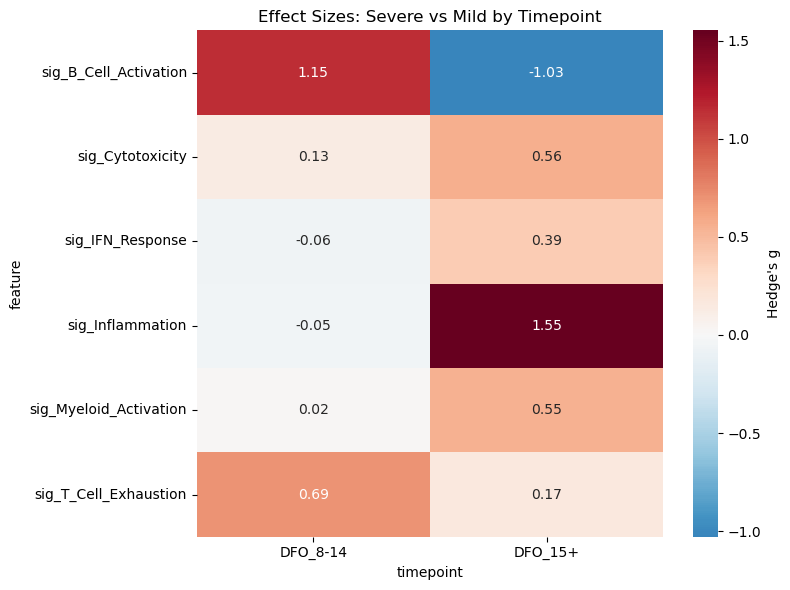

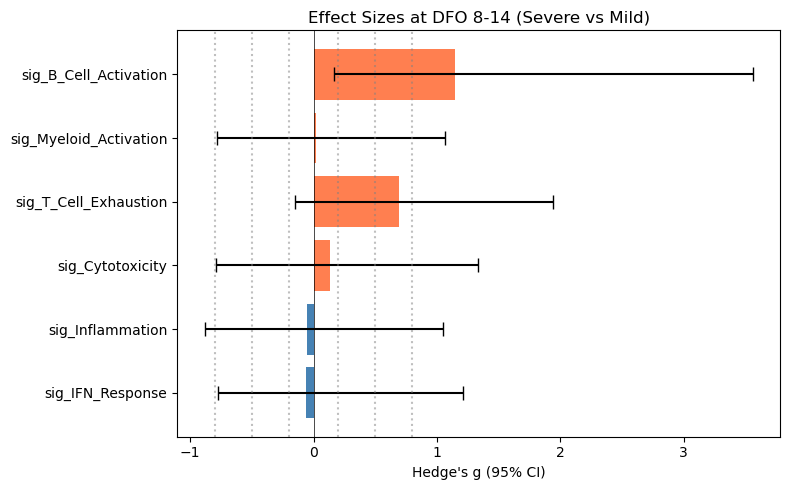

In [18]:
print("=" * 60)
print("EFFECT SIZE ANALYSIS (Cross-Sectional)")
print("=" * 60)

if signature_cols:
    # Calculate effect sizes for severity comparison at each timepoint
    effect_results = []
    
    for visit in available_visits:
        ad_visit = adata[adata.obs["dfo_bin"] == visit]
        
        # Aggregate to participant level
        df_agg = (
            ad_visit.obs
            .groupby(["participant_id", "severity"], observed=True)[signature_cols]
            .mean()
            .reset_index()
        )
        
        for sig in signature_cols:
            mild_vals = df_agg.loc[df_agg["severity"] == "Mild", sig].dropna().values
            severe_vals = df_agg.loc[df_agg["severity"] == "Severe", sig].dropna().values
            
            if len(mild_vals) >= 3 and len(severe_vals) >= 3:
                # Cohen's d and Hedge's g
                d = st.cohens_d(severe_vals, mild_vals)  # Positive = higher in Severe
                g = st.hedges_g(severe_vals, mild_vals)
                
                # Bootstrap CI (returns: effect_size, ci_lower, ci_upper)
                try:
                    _, ci_low, ci_high = st.bootstrap_effect_size_ci(
                        severe_vals, mild_vals,
                        n_boot=999,
                        alpha=0.05,
                        seed=SEED
                    )
                except Exception:
                    ci_low, ci_high = np.nan, np.nan
                
                effect_results.append({
                    "timepoint": visit,
                    "feature": sig,
                    "cohens_d": d,
                    "hedges_g": g,
                    "ci_lower": ci_low,
                    "ci_upper": ci_high,
                    "n_mild": len(mild_vals),
                    "n_severe": len(severe_vals),
                })
    
    if effect_results:
        df_effect = pd.DataFrame(effect_results)
        
        print("\nEffect sizes (Severe vs Mild):")
        print("  Positive = higher in Severe, Negative = higher in Mild")
        print("")
        display(df_effect.round(3))
        
        # Heatmap of effect sizes
        pivot = df_effect.pivot(index="feature", columns="timepoint", values="hedges_g")
        # Sort columns chronologically
        pivot = pivot[sorted(pivot.columns, key=lambda c: int(c.split("_")[1].split("-")[0].rstrip("+")))]
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            pivot, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "Hedge's g"}
        )
        plt.title("Effect Sizes: Severe vs Mild by Timepoint")
        plt.tight_layout()
        plt.show()
        
        # Forest plot for one timepoint
        visit_data = df_effect[df_effect["timepoint"] == "DFO_8-14"]
        if not visit_data.empty:
            fig, ax = plt.subplots(figsize=(8, 5))
            y_pos = np.arange(len(visit_data))
            
            ax.barh(y_pos, visit_data["hedges_g"], xerr=[
                visit_data["hedges_g"] - visit_data["ci_lower"],
                visit_data["ci_upper"] - visit_data["hedges_g"]
            ], capsize=5, color=["coral" if g > 0 else "steelblue" for g in visit_data["hedges_g"]])
            ax.axvline(0, color="black", linewidth=0.5)
            ax.set_yticks(y_pos)
            ax.set_yticklabels(visit_data["feature"])
            ax.set_xlabel("Hedge's g (95% CI)")
            ax.set_title("Effect Sizes at DFO 8-14 (Severe vs Mild)")
            
            # Reference lines
            for thresh in [-0.8, -0.5, -0.2, 0.2, 0.5, 0.8]:
                ax.axvline(thresh, color="gray", linestyle=":", alpha=0.5)
            
            plt.tight_layout()
            plt.show()
else:
    print("No signature columns for effect size analysis.")

### 13.2 Power Analysis

Power analysis helps understand what effect sizes this study could detect and plan future longitudinal studies.

**Caveat**: This dataset has **no longitudinally paired participants** for the primary
Mild vs Severe comparison. The power curves below use the average group size as a rough
guide for what a *future* paired longitudinal study of this scale could detect — they
do **not** represent the power of the current cross-sectional design. Cross-sectional
comparisons generally have lower power than paired longitudinal designs.


POWER ANALYSIS

Participants per group:


dfo_bin,DFO_0-7,DFO_8-14,DFO_15+
severity,,,
Mild,8,11,4
Severe,2,5,4



Overall: 23 Mild, 11 Severe participants
Average per group: 17

Hypothetical longitudinal DiD power (n≈17 per arm, IF paired):
  Note: This dataset has no paired participants; values are for study planning only.
  Effect size d=0.5: 30.8% power
  Effect size d=0.8: 64.5% power
  Effect size d=1.0: 83.0% power
  Effect size d=1.5: 99.2% power

Sample size for longitudinal DiD (80% power):
  (Future study planning)
  Effect size d=0.5: 63 per arm (126 total)
  Effect size d=0.8: 25 per arm (50 total)
  Effect size d=1.0: 16 per arm (32 total)

Average cells per participant: 6035


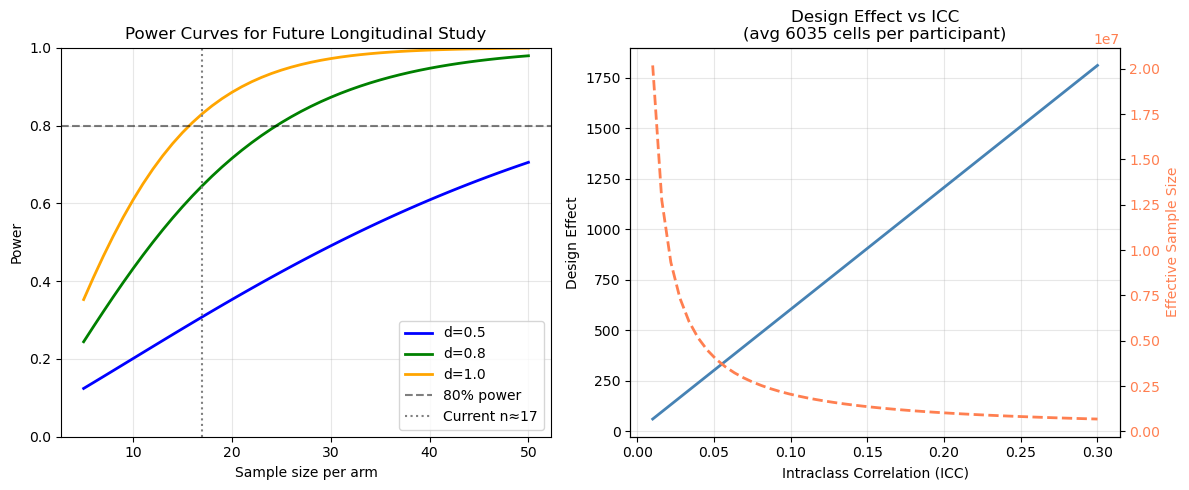


KEY INSIGHTS

1. Cross-sectional comparison:
   - Current sample provides good power for medium-large effects
   - Participant-level aggregation is critical for valid inference

2. Longitudinal limitation:
   - Only 0 participants have paired observations
   - Future studies need ≥10 paired per arm for DiD

3. Cell-level clustering:
   - With ICC=0.10 and 6035 cells/participant:
     Design effect = 604
   - This is why participant-level analysis is essential



In [19]:
print("=" * 60)
print("POWER ANALYSIS")
print("=" * 60)

# Current sample sizes by group
n_per_group = (
    adata.obs
    .groupby(["severity", "dfo_bin"], observed=True)["participant_id"]
    .nunique()
)
print("\nParticipants per group:")
display(n_per_group.unstack())

# Get typical sample sizes
n_mild = adata.obs[adata.obs["severity"] == "Mild"]["participant_id"].nunique()
n_severe = adata.obs[adata.obs["severity"] == "Severe"]["participant_id"].nunique()
n_avg = (n_mild + n_severe) / 2

print(f"\nOverall: {n_mild} Mild, {n_severe} Severe participants")
print(f"Average per group: {n_avg:.0f}")

# Power with current sample
print(f"\nHypothetical longitudinal DiD power (n≈{n_avg:.0f} per arm, IF paired):")
print("  Note: This dataset has no paired participants; values are for study planning only.")
for effect_size in [0.5, 0.8, 1.0, 1.5]:
    power = st.power_did(n_per_group=int(n_avg), effect_size=effect_size)
    print(f"  Effect size d={effect_size}: {power:.1%} power")

# Sample size needed for longitudinal DiD
print("\nSample size for longitudinal DiD (80% power):")
print("  (Future study planning)")
for effect_size in [0.5, 0.8, 1.0]:
    n_needed = st.sample_size_did(effect_size=effect_size, power=0.80)
    print(f"  Effect size d={effect_size}: {n_needed} per arm ({2*n_needed} total)")

# Power curve visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Power curves
n_range = np.arange(5, 51)
for effect_size, color in [(0.5, "blue"), (0.8, "green"), (1.0, "orange")]:
    powers = [st.power_did(n_per_group=n, effect_size=effect_size) for n in n_range]
    axes[0].plot(n_range, powers, label=f"d={effect_size}", color=color, linewidth=2)

axes[0].axhline(0.8, color="black", linestyle="--", alpha=0.5, label="80% power")
axes[0].axvline(n_avg, color="gray", linestyle=":", label=f"Current n≈{n_avg:.0f}")
axes[0].set_xlabel("Sample size per arm")
axes[0].set_ylabel("Power")
axes[0].set_title("Power Curves for Future Longitudinal Study")
axes[0].legend(loc="lower right")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# Effective sample size illustration
total_cells = adata.n_obs
cells_per_pt = adata.obs.groupby("participant_id").size().mean()
print(f"\nAverage cells per participant: {cells_per_pt:.0f}")

iccs = np.linspace(0.01, 0.30, 50)
design_effects = [st.design_effect(cells_per_pt, icc) for icc in iccs]
effective_ns = [st.effective_sample_size(total_cells, cells_per_pt, icc) for icc in iccs]

axes[1].plot(iccs, design_effects, linewidth=2, color="steelblue")
axes[1].set_xlabel("Intraclass Correlation (ICC)")
axes[1].set_ylabel("Design Effect")
axes[1].set_title(f"Design Effect vs ICC\n(avg {cells_per_pt:.0f} cells per participant)")
axes[1].grid(True, alpha=0.3)

# Add effective n on secondary axis
ax2 = axes[1].twinx()
ax2.plot(iccs, effective_ns, linewidth=2, color="coral", linestyle="--")
ax2.set_ylabel("Effective Sample Size", color="coral")
ax2.tick_params(axis='y', labelcolor='coral')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)
print(f"""
1. Cross-sectional comparison:
   - Current sample provides good power for medium-large effects
   - Participant-level aggregation is critical for valid inference

2. Longitudinal limitation:
   - Only {n_paired_dfo} participants have paired observations
   - Future studies need ≥10 paired per arm for DiD

3. Cell-level clustering:
   - With ICC=0.10 and {cells_per_pt:.0f} cells/participant:
     Design effect = {st.design_effect(cells_per_pt, 0.10):.0f}
   - This is why participant-level analysis is essential
""")

### Single-Gene Cross-Sectional Check (Participant-Level)

Here, we use a focused single-gene comparison to validate cross-sectional differences at the participant level.
This avoids pseudoreplication and provides an interpretable effect for one gene in a specific lineage.



=== Single-Gene Cross-Sectional Check (Participant-Level) ===


,gene,celltypes,group1,group2,n_group1,n_group2,mean_group1,mean_group2,delta,p_value,celltype
0,ISG15,[B_cells],Severe,Mild,10,23,1.055019,1.117754,-0.062736,0.890947,B_cells
1,ISG15,[CD4_T],Severe,Mild,11,23,0.349447,0.416083,-0.066635,0.912062,CD4_T
2,ISG15,[CD8_T],Severe,Mild,11,23,0.474734,0.659512,-0.184778,0.658669,CD8_T
3,ISG15,[DCs],Severe,Mild,10,21,0.699574,0.906295,-0.206721,0.688090,DCs
4,ISG15,[Monocytes],Severe,Mild,10,16,0.936911,1.244191,-0.307280,0.279944,Monocytes
5,ISG15,[NK],Severe,Mild,11,23,0.480815,0.571585,-0.090770,0.712779,NK
6,ISG15,[Other],Severe,Mild,11,23,0.242101,0.342777,-0.100676,0.712779,Other


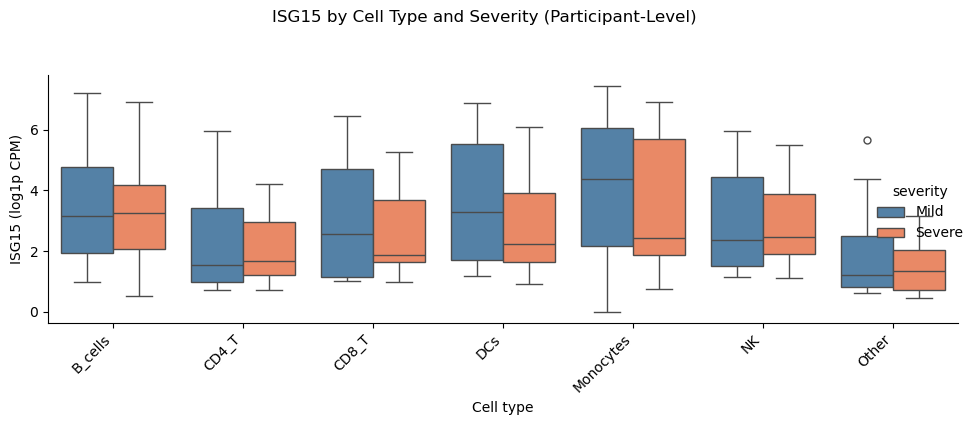

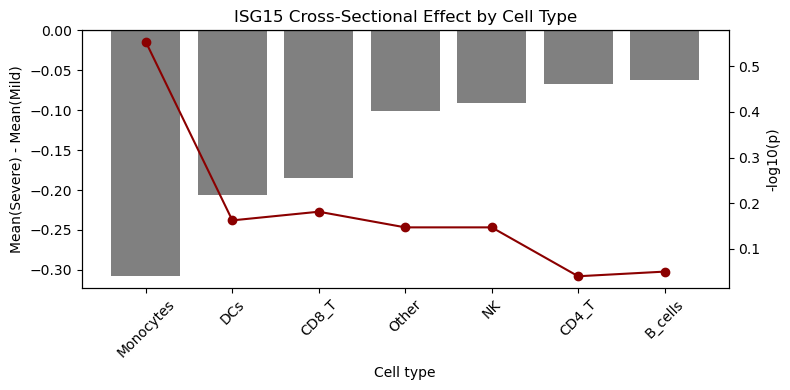

In [20]:
print("\n=== Single-Gene Cross-Sectional Check (Participant-Level) ===")
gene = "ISG15"
celltypes = sorted(adata.obs["lineage"].dropna().unique())

# Compute participant-level means per celltype and group
gene_name = st.resolve_feature(adata, gene)
# Use log1p-CPM (library-size normalized) to avoid confounding by sequencing depth
expr = st.extract_gene_vector(adata, gene_name, layer="log1p_cpm")
df_expr = adata.obs[["participant_id", "severity", "lineage"]].copy()
df_expr["expr"] = expr

df_part = (
    df_expr.groupby(["participant_id", "severity", "lineage"], observed=True)["expr"]
    .mean()
    .reset_index()
)

# Run per-celltype tests
rows = []
for ct in celltypes:
    result, _ = st.compare_gene_in_celltype(
        adata,
        gene=gene,
        celltypes=ct,
        group_col="severity",
        group1="Severe",
        group2="Mild",
        participant_col="participant_id",
        celltype_col="lineage",
        min_cells_per_patient=10,
        min_patients_per_group=3,
    )
    rows.append(result)

df_res = pd.DataFrame(rows)
df_res["celltype"] = df_res["celltypes"].apply(lambda x: x[0] if isinstance(x, list) and len(x) == 1 else str(x))
display(df_res)

# Plot participant-level distributions by celltype
g = sns.catplot(
    data=df_part,
    x="lineage",
    y="expr",
    hue="severity",
    kind="box",
    height=4,
    aspect=2.2,
    palette={"Mild": "steelblue", "Severe": "coral"},
)
g.set_xticklabels(rotation=45, ha="right")
g.set_axis_labels("Cell type", f"{gene} (log1p CPM)")
g.fig.suptitle(f"{gene} by Cell Type and Severity (Participant-Level)", y=1.05)
plt.tight_layout()
plt.show()

# Barplot of effect sizes with -log10(p) overlay
df_plot = df_res.dropna(subset=["p_value"]).copy()
if not df_plot.empty:
    df_plot["neglog10p"] = -np.log10(df_plot["p_value"].clip(lower=1e-12))
    df_plot = df_plot.sort_values("delta")
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.bar(df_plot["celltype"], df_plot["delta"], color="gray")
    ax1.axhline(0, color="black", linewidth=0.8)
    ax1.set_ylabel("Mean(Severe) - Mean(Mild)")
    ax1.set_xlabel("Cell type")
    ax1.set_title(f"{gene} Cross-Sectional Effect by Cell Type")
    ax1.tick_params(axis="x", rotation=45)
    ax2 = ax1.twinx()
    ax2.plot(df_plot["celltype"], df_plot["neglog10p"], color="darkred", marker="o")
    ax2.set_ylabel("-log10(p)")
    plt.tight_layout()
    plt.show()
else:
    print("No valid p-values available for plotting.")


### Module-Score Pseudobulk DiD by Lineage

Here, we collapse each participant×visit×lineage into a pseudobulk mean of module scores, then compute DiD per lineage. This highlights which lineages drive the severity-associated changes.

> **Note:** This dataset has no longitudinally paired participants, so the code falls back to a **repeated-cross-sectional (unpaired) OLS DiD**. This is a weaker design than a true paired DiD — treat any discoveries as **exploratory hypothesis-generating** only, not confirmatory.


No visit pair has >=2 paired participants per arm. DiD may be underpowered.
Using visits: ('DFO_0-7', 'DFO_15+')
Lineages with paired participants: ['B_cells', 'CD4_T', 'CD8_T', 'DCs', 'Monocytes', 'NK', 'Other']


,participant_id,dfo_bin,severity,pool,module,module_score,n_cells
0,AP1,DFO_15+,Severe,B_cells,sig_B_Cell_Activation,0.899969,65
1,AP1,DFO_15+,Severe,B_cells,sig_Cytotoxicity,-0.434286,65
2,AP1,DFO_15+,Severe,B_cells,sig_IFN_Response,-0.220424,65
3,AP1,DFO_15+,Severe,B_cells,sig_Inflammation,-0.356552,65
4,AP1,DFO_15+,Severe,B_cells,sig_Myeloid_Activation,-0.215348,65


/var/folders/71/dc4p4yz15s74z9c69xy6sk_00000gt/T/ipykernel_25564/2438914800.py:67: UserWarning: FDR correction is applied within each 'module' group (column FDR_DiD). Per-group FDR does not control the overall false discovery rate across all tests. Consult FDR_DiD_global (when fdr_global=True) for a globally corrected q-value.
  return st.module_score_did_by_pool(


,pool,module,mean_delta_treated,mean_delta_control,beta_DiD,p_DiD,p_treated,p_control,n_units,FDR_DiD,FDR_DiD_global
10,CD4_T,sig_Myeloid_Activation,0.033539,-0.022396,0.055934,0.005882,1.448392e-02,1.435256e-01,18,0.041177,0.247059
39,Other,sig_Inflammation,0.063717,-0.031208,0.094925,0.060188,9.327552e-02,3.731571e-01,18,0.421313,0.766013
0,B_cells,sig_B_Cell_Activation,0.023480,0.316719,-0.293239,0.088852,7.913530e-01,3.046176e-02,18,0.287586,0.766013
12,CD8_T,sig_B_Cell_Activation,0.084332,-0.041179,0.125511,0.090395,1.523304e-01,3.956929e-01,18,0.287586,0.766013
36,Other,sig_B_Cell_Activation,-0.062174,0.331806,-0.393980,0.123251,7.678999e-01,3.764561e-02,18,0.287586,0.766013
9,CD4_T,sig_Inflammation,0.025529,-0.057104,0.082633,0.148328,5.669148e-01,1.350545e-01,18,0.454691,0.766013
22,DCs,sig_Myeloid_Activation,0.342098,0.152212,0.189887,0.163697,4.228575e-03,4.767019e-02,18,0.306405,0.766013
40,Other,sig_Myeloid_Activation,0.032732,-0.017220,0.049952,0.177722,2.535658e-01,4.907715e-01,18,0.306405,0.766013
5,B_cells,sig_T_Cell_Exhaustion,0.161363,-0.061513,0.222876,0.186291,2.116081e-01,5.922744e-01,18,0.906840,0.766013
33,NK,sig_Inflammation,0.108476,0.020518,0.087958,0.194868,2.098862e-02,6.833466e-01,18,0.454691,0.766013


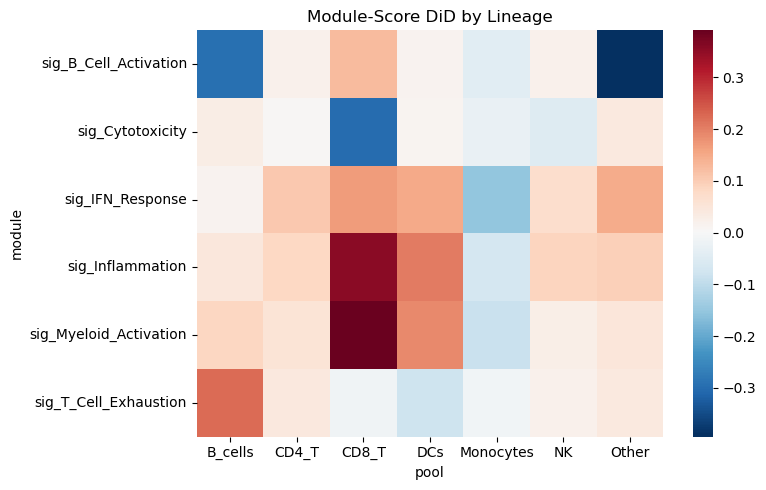

In [21]:
if signature_cols:
    # Choose visit pair with best paired coverage across arms
    visit_levels = sorted(adata.obs["dfo_bin"].dropna().unique())
    best_pair = None
    best_score = -1
    min_per_arm = 2
    for v1, v2 in itertools.combinations(visit_levels, 2):
        wide = (
            adata.obs
            .groupby(["participant_id", "dfo_bin"], observed=True)
            .size()
            .unstack(fill_value=0)
        )
        paired_ids = wide[(wide.get(v1, 0) > 0) & (wide.get(v2, 0) > 0)].index
        if len(paired_ids) == 0:
            continue
        arm_counts = (
            adata.obs[adata.obs["participant_id"].isin(paired_ids)]
            .groupby("severity")["participant_id"]
            .nunique()
        )
        if len(arm_counts) < 2:
            continue
        min_arm = min(arm_counts.get("Severe", 0), arm_counts.get("Mild", 0))
        if min_arm < min_per_arm:
            continue
        if min_arm > best_score:
            best_score = min_arm
            best_pair = (v1, v2)

    allow_unpaired = False
    if best_pair is None:
        print("No visit pair has >=2 paired participants per arm. DiD may be underpowered.")
        visits_pair = tuple(visit_levels[:2])
        allow_unpaired = True
        # Fallback: repeated-cross-sectional OLS DiD (weaker than paired)
    else:
        visits_pair = best_pair
    print("Using visits:", visits_pair)

    # Filter lineages with enough paired participants for the chosen pair
    paired_counts = (
        adata.obs[adata.obs["dfo_bin"].isin(visits_pair)]
        .groupby(["participant_id", "lineage"])["dfo_bin"]
        .nunique()
        .reset_index(name="n_visits")
    )
    paired_lineages = paired_counts[paired_counts["n_visits"] >= 2]["lineage"].value_counts()
    keep_lineages = paired_lineages[paired_lineages >= 2].index.tolist()
    if not keep_lineages:
        keep_lineages = sorted(adata.obs["lineage"].dropna().unique())

    print("Lineages with paired participants:", keep_lineages)

    adata_use = adata[adata.obs["lineage"].isin(keep_lineages)].copy()
    pb_mod = st.module_score_pseudobulk(
        adata_use,
        module_cols=signature_cols,
        design=design,
        visits=visits_pair,
        pool_col="lineage",
        min_cells_per_group=1,
    )
    display(pb_mod.head())

    def _run_mod_did(pb_df, allow_unpaired_flag):
        return st.module_score_did_by_pool(
            pb_df,
            design=design,
            visits=visits_pair,
            min_paired=2,
            n_perm=300,
            seed=SEED,
            fdr_within="module",
            allow_unpaired=allow_unpaired_flag,
        )

    res_mod = _run_mod_did(pb_mod, allow_unpaired)
    if res_mod.empty and not allow_unpaired:
        print("No valid paired lineage-level DiD results. Retrying with unpaired OLS DiD.")
        res_mod = _run_mod_did(pb_mod, True)

    if res_mod.empty:
        print("No valid lineage-level DiD results. Falling back to pooled lineage.")
        pb_all = st.module_score_pseudobulk(
            adata_use,
            module_cols=signature_cols,
            design=design,
            visits=visits_pair,
            pool_map={"All_Lineages": keep_lineages},
            celltype_col="lineage",
            min_cells_per_group=1,
        )
        res_mod = st.module_score_did_by_pool(
            pb_all,
            design=design,
            visits=visits_pair,
            min_paired=2,
            n_perm=300,
            seed=SEED,
            fdr_within=None,
            allow_unpaired=True,
        )

    if not res_mod.empty:
        display(res_mod.sort_values("p_DiD").head(20))
        pivot = res_mod.pivot(index="module", columns="pool", values="beta_DiD")
        plt.figure(figsize=(8, 5))
        sns.heatmap(pivot, cmap="RdBu_r", center=0)
        plt.title("Module-Score DiD by Lineage")
        plt.tight_layout()
        plt.show()
    else:
        print("No valid module-score DiD results after fallback.")
else:
    print("No module scores available for pseudobulk DiD.")


### Parallel Trends Visualization (Early Visits)

Here we visualize pre-treatment trends across early visits to assess whether arms move in parallel before divergence. This is a diagnostic, not a formal test.


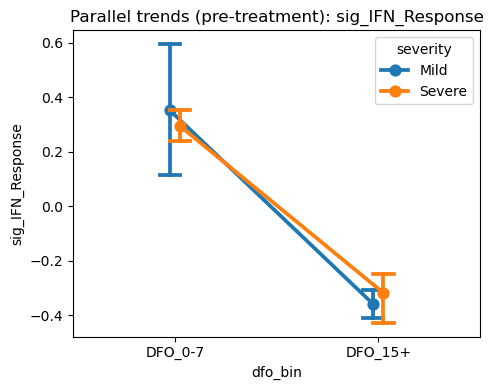

In [22]:
if signature_cols:
    try:
        st.plot_parallel_trends(
            adata,
            feature=signature_cols[0],
            design=design,
            visits=visits_pair,
        )
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'Parallel trends plot skipped: {e}')
